In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Admission_Predict.csv')

In [3]:
df.sample(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
104,105,326,112,3,3.5,3.0,9.05,1,0.74
65,66,325,112,4,3.5,3.5,8.92,0,0.55
273,274,312,99,1,1.0,1.5,8.01,1,0.52
185,186,327,113,4,4.5,4.5,9.11,1,0.89
47,48,339,119,5,4.5,4.0,9.70,0,0.89


In [5]:
df.drop(columns = ['Serial No.'] , inplace=True)

In [6]:
df.sample(5)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
183,314,110,3,4.0,4.0,8.80,0,0.75
124,301,106,4,2.5,3.0,8.47,0,0.57
194,316,109,3,3.5,3.0,8.76,0,0.77
398,312,103,3,3.5,4.0,8.78,0,0.67
338,323,108,5,4.0,4.0,8.74,1,0.81


In [10]:
df = pd.get_dummies(df , columns=['Research'] , dtype='int64' , drop_first=True)

In [11]:
df.sample(5)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit,Research_1
376,297,96,2,2.5,2.0,7.43,0.34,0
68,318,109,3,3.5,4.0,9.22,0.68,1
274,315,100,1,2.0,2.5,7.95,0.58,0
199,313,107,3,4.0,4.5,8.69,0.72,0
382,324,110,4,4.5,4.0,9.15,0.82,1


In [16]:
X = df.drop(columns=["Chance of Admit "])
y = df['Chance of Admit ']

In [15]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Chance of Admit ', 'Research_1'],
      dtype='object')

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [22]:
model = Sequential()

In [23]:
model.add(Dense(10 , activation = 'relu' , input_dim = 7))
model.add(Dense(5 ,activation = 'relu'))
model.add(Dense(3 ,activation = 'relu'))
model.add(Dense(1 ,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157 (628.00 B)

 Trainable params: 157 (628.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer='Adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [26]:
history = model.fit(X_train_trf , y_train , batch_size = 20 , epochs=100 , validation_split=0.2)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.0000e+00 - loss: 0.6168 - val_accuracy: 0.0000e+00 - val_loss: 0.5874
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 0.6090 - val_accuracy: 0.0000e+00 - val_loss: 0.5692
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 0.5880 - val_accuracy: 0.0000e+00 - val_loss: 0.5545
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0000e+00 - loss: 0.5551 - val_accuracy: 0.0000e+00 - val_loss: 0.5443
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0000e+00 - loss: 0.5780 - val_accuracy: 0.0000e+00 - val_loss: 0.5388
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 0.5709 - val_accuracy: 0.0000e+00 - val_loss: 0.5361
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0000e+00 - loss: 0.5543 - val_accuracy: 0.0000e+00 - val_loss: 0.5350
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/s

In [27]:
y_pred = model.predict(X_test_trf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [28]:
y_pred

array([[0.692066  ],
       [0.72028255],
       [0.79644483],
       [0.766561  ],
       [0.84307736],
       [0.5905078 ],
       [0.60022634],
       [0.5188819 ],
       [0.528096  ],
       [0.9323385 ],
       [0.8116852 ],
       [0.9395745 ],
       [0.9060686 ],
       [0.6328665 ],
       [0.7513795 ],
       [0.6572247 ],
       [0.8194367 ],
       [0.90005624],
       [0.5188819 ],
       [0.66124475],
       [0.67191225],
       [0.77789086],
       [0.8402792 ],
       [0.91632086],
       [0.67313355],
       [0.55327624],
       [0.72680813],
       [0.6418278 ],
       [0.91980374],
       [0.66086704],
       [0.9419065 ],
       [0.647522  ],
       [0.8121193 ],
       [0.7858417 ],
       [0.6622441 ],
       [0.6247177 ],
       [0.5250113 ],
       [0.6361597 ],
       [0.91063726],
       [0.7631944 ],
       [0.8608259 ],
       [0.6371078 ],
       [0.90172005],
       [0.5347315 ],
       [0.95416963],
       [0.71494204],
       [0.7255704 ],
       [0.830

In [29]:
y_pred = (y_pred > 0.5).astype(int)

In [31]:
y_pred.reshape(y_test.shape)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [32]:
y_test = (y_test > 0.5).astype(int)

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8875

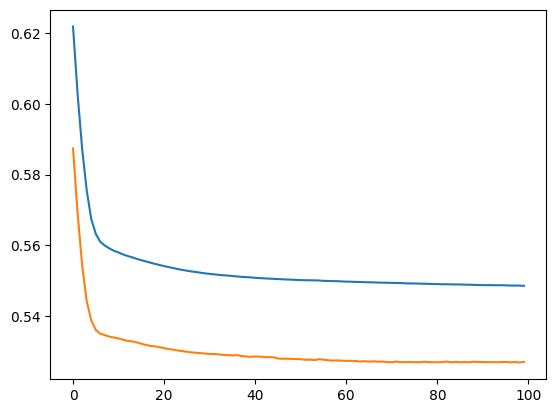

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

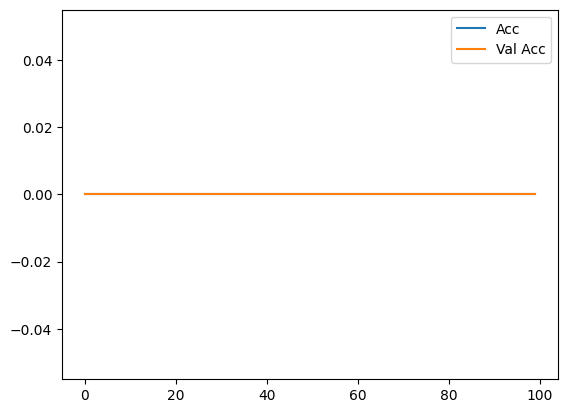

In [35]:
plt.plot(history.history['accuracy'] , label = "Acc")
plt.plot(history.history['val_accuracy'] , label="Val Acc")
plt.legend()
plt.show()

In [36]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model1.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [40]:
history1 = model1.fit(
    X_train_trf,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.4706 - mae: 0.6137 - val_loss: 0.1066 - val_mae: 0.2681
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0799 - mae: 0.2334 - val_loss: 0.0693 - val_mae: 0.2120
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0458 - mae: 0.1690 - val_loss: 0.0518 - val_mae: 0.1800
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0339 - mae: 0.1451 - val_loss: 0.0355 - val_mae: 0.1446
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0260 - mae: 0.1301 - val_loss: 0.0280 - val_mae: 0.1300
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0192 - mae: 0.1089 - val_loss: 0.0220 - val_mae: 0.1140
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0154 - mae: 0.0975 - val_loss: 0.0174 - val_mae: 0.1021
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0129 - mae: 0.0907 - val_loss: 0.0133 - val_mae: 0.0887
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss:

In [51]:
loss, mae = model1.evaluate(X_test, y_test)
print("Test MAE:", mae)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4339.0967 - mae: 65.8294 
Test MAE: 65.69682312011719


In [42]:
y_pred1 = model1.predict(X_test_trf)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


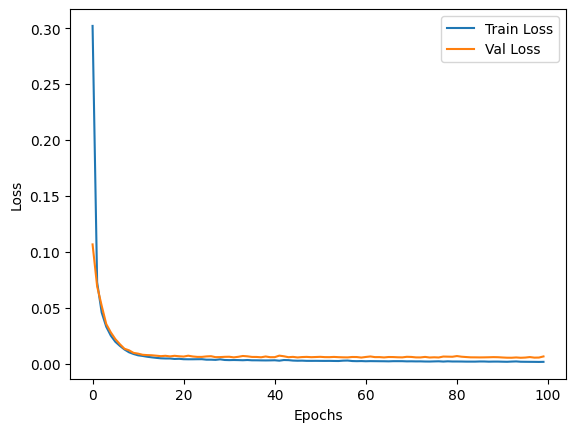

In [43]:
import matplotlib.pyplot as plt

plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [49]:
mae = mean_absolute_error(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred1)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.06100718840956687
RMSE: 0.07709503286745874
R²  : 0.7430046414422461


In [50]:
df.shape

(400, 8)